
<h1 id="DSSD-front-back-Correlation(I)---dssd1">DSSD front-back Correlation(I) - dssd1</h1><h2 id="Front-Back-Energy-Correlation">Front-Back Energy Correlation</h2><p>When a single charged particle hits the intersection of front strip $X_i$ and back strip $Y_j$ in a DSSD, the charges collected on the two sides originate from the same deposited energy. For an ideal single-pixel event,</p>
<p>$$
E_{\mathrm{true}} = E_{x,i} = E_{y,j}.
$$</p>
<p>Therefore, the front-side and back-side signals should show a one-to-one energy correlation.</p>
<p>In the DAQ system, however, the directly recorded quantities are the raw ADC amplitudes $A_{x,i}$ and $A_{y,j}$, rather than the physical energies themselves. Because the electronic response differs from strip to strip, the raw amplitudes on the two sides are correlated, but not yet directly comparable on a common scale.</p>
<p>The purpose of the present tutorial is to use this front-back correlation of purified single-pixel events to establish a detector-internal relative energy normalization.</p>
<p><img alt="" src="fig/dssd-fb.png" width="1000"/></p>
<h2 id="Relative-Energy-Calibration">Relative Energy Calibration</h2><p>To compare signals from different strips, we introduce a unified <strong>relative energy scale</strong> inside the detector.</p>
<p>Choose one front strip $X_r$ as the baseline reference and define</p>
<p>$$
E^{(\mathrm{rel})} \equiv A_{x,r},
\qquad
k_{x,r}=1,
\qquad
b_{x,r}=0.
$$</p>
<p>Then each strip is mapped onto this common relative scale by a linear transformation:</p>
<p>$$
E_{x,i}^{(\mathrm{rel})} = k_{x,i} A_{x,i} + b_{x,i},
\qquad
E_{y,j}^{(\mathrm{rel})} = k_{y,j} A_{y,j} + b_{y,j}.
$$</p>
<p>Here $A_{x,i}$ and $A_{y,j}$ are the raw amplitudes measured on strips $X_i$ and $Y_j$, while $(k,b)$ are the strip-wise calibration parameters.</p>
<p>For a correctly paired single-pixel event, the normalized front-side and back-side energies should satisfy</p>
<p>$$
E_{x,i}^{(\mathrm{rel})} \approx E_{y,j}^{(\mathrm{rel})}.
$$</p>
<p>The task of relative calibration is therefore to determine the parameters $(k,b)$ so that this front-back consistency is achieved on purified correlation data.</p>
<hr/>
<h2 id="Multi-hit-position-matching">Multi-hit position matching</h2><p>The relative energy normalization established here is the basis for later front-back pairing in multi-hit events. Once all strip signals are mapped onto a common scale, the consistency between normalized front-side and back-side energies can be used as an additional constraint for resolving pairing ambiguity.</p>
<p>Assume two particles strike the detector at the same time, producing true hit points at $(X_1, Y_1)$ and $(X_2, Y_2)$ with distinct energies ($E_1 \neq E_2$). The readout system records signals from front strips $X_1, X_2$ and back strips $Y_1, Y_2$. Relying solely on geometric topology, it is impossible to distinguish whether the genuine physical combination is $\{(X_1, Y_1), (X_2, Y_2)\}$ or the spurious "ghost" combination $\{(X_1, Y_2), (X_2, Y_1)\}$.</p>
<p>By normalizing all strip signals to the unified scale $E^{(\mathrm{rel})}$, we can construct a residual criterion based on the physical principle of front-back energy consistency:</p>
<p>$$
\Delta E = |E^{(\mathrm{rel})}_{x} - E^{(\mathrm{rel})}_{y}|
$$</p>
<p><strong>Physical Matching Criterion: For a correctly paired front-back strip combination, their normalized energy difference $\Delta E$ should be minimized (approaching zero).</strong> Therefore, relative normalization serves as an essential prerequisite for precise multi-particle identification and position reconstruction.</p>
<p><img alt="" src="fig/dssd_2hit.png" width="400"/></p>
<p>In the present tutorial, however, we focus only on purified single-pixel events and the extraction of the relative calibration coefficients.</p>
<h2 id="Pixel-Pixel-Calibration-Method">Pixel-Pixel Calibration Method</h2><p>In this tutorial, we consider the simplest calibration strategy: <strong>pixel-pixel correlation</strong>.</p>
<p>Fix one front strip $X_{i^*}$ as the reference. For each back strip $Y_j$, select events belonging to the pixel $(i^*,j)$ and fit</p>
<p>$$
A_{x,i^*} = k_{y,j} A_{y,j} + b_{y,j}.
$$</p>
<p>This determines the relative calibration of the back strip $Y_j$:</p>
<p>$$
E_{y,j}^{(\mathrm{rel})} = k_{y,j} A_{y,j} + b_{y,j}.
$$</p>
<p>Then choose one calibrated back strip $Y_{j^*}$ as the new reference and fit each front strip $X_k$,</p>
<p>$$
E_{y,j^*}^{(\mathrm{rel})} = k_{x,k} A_{x,k} + b_{x,k},
$$</p>
<p>so that</p>
<p>$$
E_{x,k}^{(\mathrm{rel})} = k_{x,k} A_{x,k} + b_{x,k}.
$$</p>
<p>This method directly uses the front-back correlation at the level of individual pixels. It is conceptually straightforward, but its quality depends on whether the selected pixels contain sufficient statistics.</p>
<p>In the present tutorial, we restrict ourselves to this pixel-pixel method. A more global strip-strip normalization strategy will be introduced in a later tutorial.</p>



<h2 id="Detector-Setup">Detector Setup</h2><p><strong>ROOT File:</strong> <code>data_16C.root</code></p>
<ul>
<li><strong>Reaction System:</strong> 25 MeV/A $^{16}$C + $^9$Be, measuring forward-angle multiple charged particles produced from the fragmentation of $^{16}$C.</li>
<li><strong>Detector Array:</strong> A telescope array consisting of 3 DSSDs + CsI, positioned at zero degrees behind the target.<ul>
<li>D1, D2, and D3 are all double-sided silicon strip detectors with 32 (X) $\times$ 32 (Y) strips.</li>
<li>Strip width: 2 mm, inter-strip spacing: 0.1 mm.</li>
</ul>
</li>
<li><strong>Hardware Trigger:</strong> Requires at least two hits on the X-side of both D1 and D2 (Multiplicity $\ge$ 2).</li>
<li><strong>Data Preprocessing:</strong> Pedestal events have been removed.</li>
</ul>
<p><img alt="" src="fig/Setup.png" width="400"/></p>
<p><strong>Branch:</strong></p>
<div class="highlight"><pre><span></span><span class="c1">// xenergy, yenergy, xtime (Array of 32 for each detector)</span>
<span class="n">d1x</span><span class="p">[</span><span class="mi">32</span><span class="p">],</span><span class="w"> </span><span class="n">d1y</span><span class="p">[</span><span class="mi">32</span><span class="p">],</span><span class="w"> </span><span class="n">d1t</span><span class="p">[</span><span class="mi">32</span><span class="p">];</span><span class="w"> </span>
<span class="n">d2x</span><span class="p">[</span><span class="mi">32</span><span class="p">],</span><span class="w"> </span><span class="n">d2y</span><span class="p">[</span><span class="mi">32</span><span class="p">],</span><span class="w"> </span><span class="n">d2t</span><span class="p">[</span><span class="mi">32</span><span class="p">];</span>
<span class="n">d3x</span><span class="p">[</span><span class="mi">32</span><span class="p">],</span><span class="w"> </span><span class="n">d3y</span><span class="p">[</span><span class="mi">32</span><span class="p">],</span><span class="w"> </span><span class="n">d3t</span><span class="p">[</span><span class="mi">32</span><span class="p">];</span>

<span class="c1">// hit multiplicity, energy, time, strip ID (Compact arrays based on hits)</span>
<span class="n">d1xhit</span><span class="p">,</span><span class="w"> </span><span class="n">d1xe</span><span class="p">[</span><span class="n">d1xhit</span><span class="p">],</span><span class="w"> </span><span class="n">d1xt</span><span class="p">[</span><span class="n">d1xhit</span><span class="p">],</span><span class="w"> </span><span class="n">d1xs</span><span class="p">[</span><span class="n">d1xhit</span><span class="p">];</span><span class="w"> </span>
<span class="n">d2xhit</span><span class="p">,</span><span class="w"> </span><span class="n">d2xe</span><span class="p">[</span><span class="n">d2xhit</span><span class="p">],</span><span class="w"> </span><span class="n">d2xt</span><span class="p">[</span><span class="n">d2xhit</span><span class="p">],</span><span class="w"> </span><span class="n">d2xs</span><span class="p">[</span><span class="n">d2xhit</span><span class="p">];</span><span class="w"> </span>
<span class="n">d3xhit</span><span class="p">,</span><span class="w"> </span><span class="n">d3xe</span><span class="p">[</span><span class="n">d3xhit</span><span class="p">],</span><span class="w"> </span><span class="n">d3xt</span><span class="p">[</span><span class="n">d3xhit</span><span class="p">],</span><span class="w"> </span><span class="n">d3xs</span><span class="p">[</span><span class="n">d3xhit</span><span class="p">];</span>
<span class="n">d1yhit</span><span class="p">,</span><span class="w"> </span><span class="n">d1ye</span><span class="p">[</span><span class="n">d1yhit</span><span class="p">],</span><span class="w"> </span><span class="n">d1yt</span><span class="p">[</span><span class="n">d1yhit</span><span class="p">],</span><span class="w"> </span><span class="n">d1ys</span><span class="p">[</span><span class="n">d1yhit</span><span class="p">];</span><span class="w"> </span>
<span class="n">d2yhit</span><span class="p">,</span><span class="w"> </span><span class="n">d2ye</span><span class="p">[</span><span class="n">d2yhit</span><span class="p">],</span><span class="w"> </span><span class="n">d2yt</span><span class="p">[</span><span class="n">d2yhit</span><span class="p">],</span><span class="w"> </span><span class="n">d2ys</span><span class="p">[</span><span class="n">d2yhit</span><span class="p">];</span><span class="w"> </span>
<span class="n">d3yhit</span><span class="p">,</span><span class="w"> </span><span class="n">d3ye</span><span class="p">[</span><span class="n">d3yhit</span><span class="p">],</span><span class="w"> </span><span class="n">d3yt</span><span class="p">[</span><span class="n">d3yhit</span><span class="p">],</span><span class="w"> </span><span class="n">d3ys</span><span class="p">[</span><span class="n">d3yhit</span><span class="p">];</span>
</pre></div>


In [ ]:
TFile *ipf = new TFile("./data/data_16C.root");
TTree *tree = (TTree*)ipf->Get("tree");
TCanvas *c1 = new TCanvas("c1","c1");

<h3>Multiplicity for X and Y Sides</h3><p>硬件 multiplicity 条件影响样本组成。软件阈值、读出效率和能量共享会使离线 hit 数与触发 hit 数不同；X 侧触发也不保证 Y 侧具有相同 multiplicity。</p>

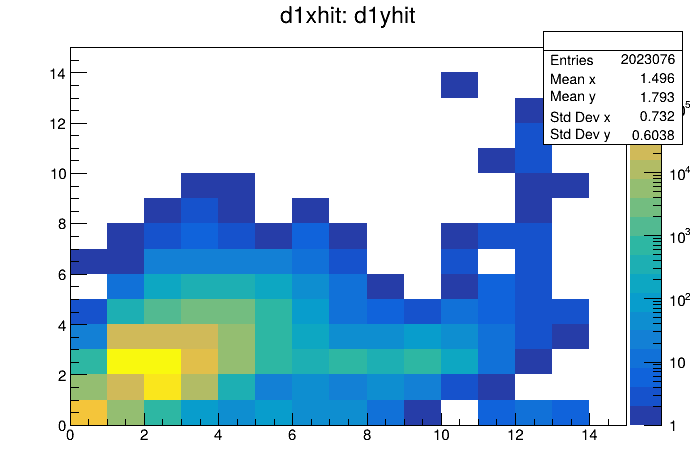

In [5]:
tree->Draw("d1xhit: d1yhit>>(15, 0, 15, 15, 0, 15)", "", "colz");
gPad->SetLogz();
c1->Draw();

<p>多条信号可能来自多个粒子，也可能来自一个粒子的电荷共享或串扰。仅凭这张 multiplicity 图还不能确定各类的比例，下面继续检查条号和能量关联。</p>

In [7]:
tree->Scan("d1xe: d1xs: d1ye: d1ys", "", "", 10, 1);

***********************************************************************
*    Row   * Instance *      d1xe *      d1xs *      d1ye *      d1ys *
***********************************************************************
*        1 *        0 *      4800 *        17 *      5775 *        18 *
*        1 *        1 *       982 *        18 *           *           *
*        2 *        0 *      3069 *        23 *      3352 *        11 *
*        2 *        1 *       341 *        24 *       111 *        10 *
*        3 *        0 *      5325 *        23 *      4522 *        15 *
*        3 *        1 *           *           *       922 *        16 *
*        4 *        0 *      5822 *        21 *      5688 *        15 *
*        4 *        1 *           *           *       271 *        14 *
*        5 *        0 *      4048 *        11 *      5213 *        12 *
*        5 *        1 *      1149 *        12 *           *           *
*        6 *        0 *      3719 *        14 *      4255 *     


<p><strong>Front-Back Correlation</strong></p>
<p>A clear linear correlation band is observed in the central region. However, prominent scattered points outside this band result from <strong>Charge Sharing</strong>—where the deposited energy splits between adjacent strips, causing the energy recorded in a single strip to be less than the total deposited energy.</p>


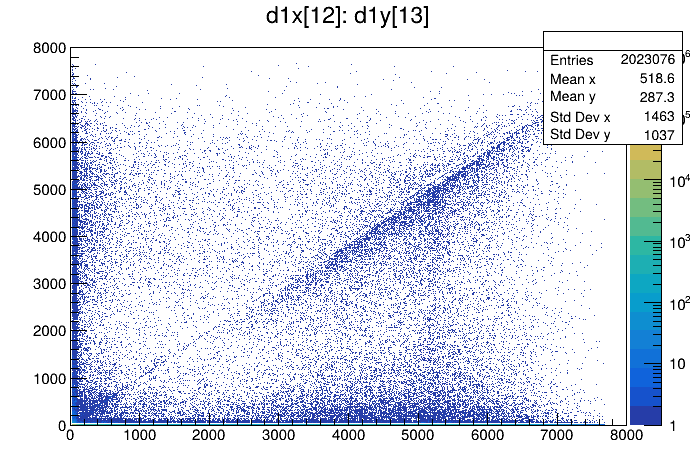

In [9]:
gPad->SetLogy(0);
tree->Draw("d1x[12]: d1y[13]>>(1000, 0, 8000, 1000, 0, 8000)", "", "colz");
c1->Draw();//front-back correlation


<p><strong>X-Y Correlations Unaffected by Adjacent Strip Energy Sharing</strong></p>
<p>To mitigate the impact of energy sharing between adjacent strips, two approaches are traditionally considered:</p>
<p><strong>1. Global Single Multiplicity Requirement:</strong> Require exactly one hit on both X and Y sides (<code>xhit==1 &amp;&amp; yhit==1</code>). This effectively eliminates scattered points but results in severely low event statistics due to our specific hardware trigger condition ($M \ge 2$).</p>


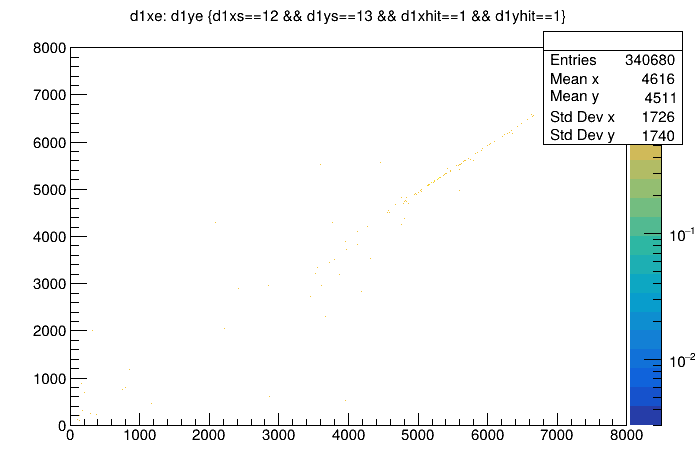

In [11]:
c1->Clear();
TCut chit1 = "d1xs==12 && d1ys==13 && d1xhit==1 && d1yhit==1";
tree->Draw("d1xe: d1ye>>(1000, 0, 8000, 1000, 0, 8000)", chit1, "colz");
c1->Draw();


<p><strong>2. Local Isolation Cut (Anti-coincidence Condition):</strong> Instead of restricting global multiplicity, strictly require that the selected pixel has no signal in its immediate spatially adjacent strips.</p>
<ul>
<li>Use a threshold of <code>&lt; 50</code> channels (representing the hardware pedestal/noise limit). Ensuring neighboring strips are below this threshold suppresses detectable neighboring-strip signals; sharing below threshold can remain.</li>
<li>For <code>d1x[12]</code>: Strips 11 and 13 must have no signal (<code>&lt; 50</code>).</li>
<li>For <code>d1y[13]</code>: Strips 12 and 14 must have no signal (<code>&lt; 50</code>).</li>
</ul>
<p>Applying this local isolation condition significantly recovers usable event statistics while maintaining high purity of the linear response.</p>


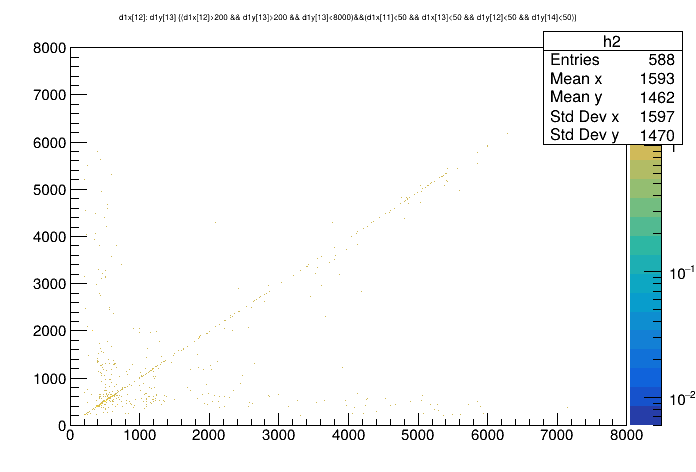

In [13]:
c1->Clear();
TCut cveto = "d1x[11]<50 && d1x[13]<50 && d1y[12]<50 && d1y[14]<50"; // no sharing
TCut c1213 = "d1x[12]>200 && d1y[13]>200 && d1y[13]<8000" && cveto;
tree->Draw("d1x[12]: d1y[13]>>h2(1000, 0, 8000, 1000, 0, 8000)", c1213, "colz");
c1->Draw();

<h3>1. 取出逐事例关联数据</h3><p>将所选事例直接交给 TGraph 做 unbinned 直线拟合，避免把 TH2 的 bin 中心当成测量值。TH2 用来显示同一批事例；并不是所有关联拟合都必须采用这种做法。</p>

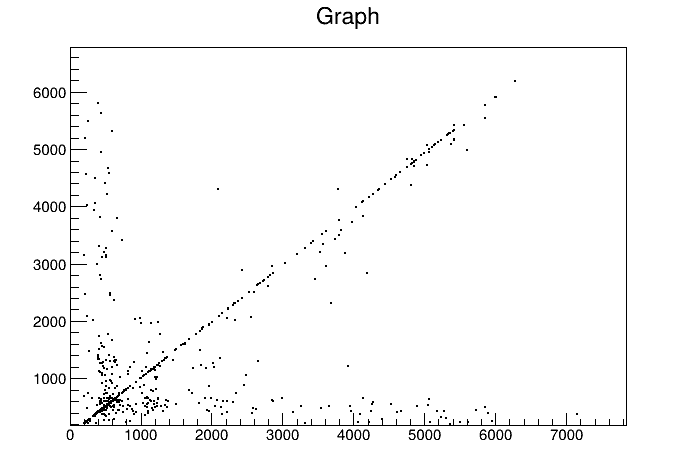

In [15]:
tree->SetEstimate(tree->GetEntries()+1);
tree->Draw("d1x[12]:d1y[13]", c1213, "goff");
TGraph *gr = new TGraph(tree->GetSelectedRows(), tree->GetV2(), tree->GetV1());
gr->SetMarkerSize(0.2);
gr->Draw("A*");
c1->Draw();


<p><strong>2. Standard vs. Robust Regression</strong></p>
<p><strong>Standard Least Squares (<code>pol1</code>):</strong> Severely biased by residual, uncleaned cross-talk outliers. These sparse extreme points act as "levers," pulling the fit away from the true diagonal.</p>
<p><strong>Robust Fitting (<code>"ROB"</code>):</strong> ROOT's robust fitting utilizes Least Trimmed Squares to automatically down-weight extreme outliers not originating from the main data-generating process.</p>
<h3 id="ROBUST-REGRESSION">ROBUST REGRESSION</h3><p>In the presence of outliers that do not come from the same data-generating process as the rest of the data, least squares estimation is inefficient and can be biased. Robust regression methods are designed to be not overly affected by violations of assumptions by the underlying data-generating process. ROOT supports robust fitting for polynomial functions using the <code>"ROB"</code> option.
<a href="https://root.cern/doc/master/fitLinearRobust_8C.html">https://root.cern/doc/master/fitLinearRobust_8C.html</a></p>
<p><img alt="" src="fig/pict1_fitLinearRobust.C.png" width="500"/></p>
<p>此处的 ROB 由 ROOT linear fitter 执行，适用于参数线性的模型，并不限于多项式；一般非线性 TF1 不能直接套用这个选项。</p>


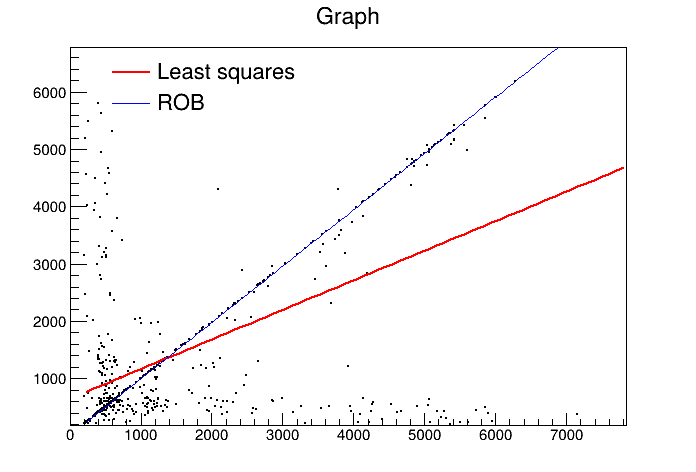

In [17]:
// 1. Standard Fit (Least Squares)
TF1 *fStd = new TF1("fStd", "pol1", 200, 8000);
fStd->SetLineColor(kRed);
gr->Fit(fStd, "RQ"); 

// 2. Robust Fit (Least Trimmed Squares)
TF1 *fRob = new TF1("fRob", "pol1", 200, 8000);
fRob->SetLineColor(kBlue);
fRob->SetLineWidth(1);
// The "+" option adds the new function to the graph's list, preserving the previous one
gr->Fit(fRob, "R+ ROB Q"); 

// Draw the graph with points
gr->Draw("A*");

// 3. Add Legend for visual comparison
// (Positioned at top-left to avoid overlapping the y=x diagonal data)
TLegend *leg = new TLegend(0.15, 0.75, 0.45, 0.88);
leg->SetBorderSize(0);
leg->AddEntry(fStd, "Least squares", "l");
leg->AddEntry(fRob, "ROB", "l");
leg->Draw();

c1->Draw();

<h3>3. 残差与幅度的关系</h3><p>定义 residual 为 <code>d1x[12] − (p0 + p1*d1y[13])</code>。直线描述合适时，主条带应在零附近，且不随幅度出现系统趋势。若有趋势，应检查模型、两轴测量误差、阈值和残留混合事件；不能仅凭低能端事例较多就判定为“统计假象”，也不能据此排除电子学非线性。</p>

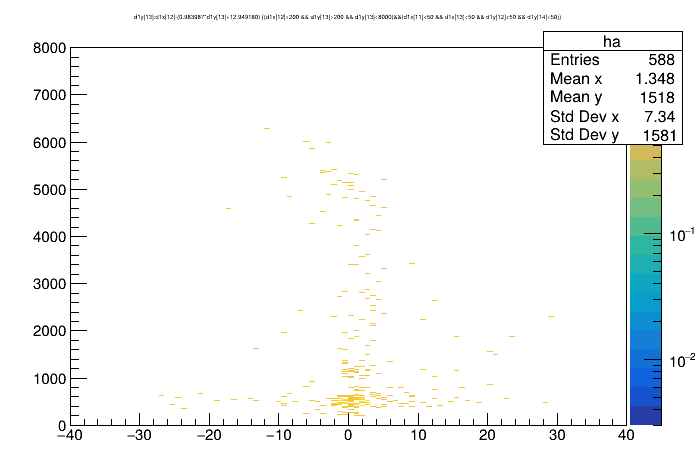

In [19]:
// Extract the parameters from the Robust Fit
double p0 = fRob->GetParameter(0);
double p1 = fRob->GetParameter(1);

// Construct the draw command for the residual: Y vs (X - (p1*Y + p0))
TString stree;
stree.Form("d1y[13]:d1x[12]-(%f*d1y[13]+%f)>>ha(100,-40,40,1000,0,8000)", p1, p0);

// Ensure the pad is cleared and ready for a 2D color plot
c1->Clear();
tree->Draw(stree.Data(), c1213, "colz");
c1->Draw();


<h3 id="assignment">Assignment</h3><p>Save the highly purified single-pixel events from DSSD 1/2/3—strictly applying the local isolation cut to exclude adjacent charge sharing—into structured <code>d1/2/3xy.root</code> files. TThese files will serve as the data foundation for the subsequent front-back relative calibration studies.</p>
<p><strong>1. Global 2D Correlation Filter (<code>cut1/2/3.C</code>)</strong>
Create a rough geometric boundary to enclose the main $Y \approx X$ diagonal band. Draw a 2D scatter plot under ideal clean conditions (<code>xhit==1 &amp;&amp; yhit==1</code>), use the ROOT TBrowser Graphical Cut to draw a polygon, and save it as a macro (e.g., <code>cut1.C</code>). This topologically rejects massive far-field noises.</p>
<p><strong>2. Event Extraction Code Structure</strong></p>
<div class="highlight"><pre><span></span><span class="c1">// Load the global 2D graphical filter</span>
<span class="n">gROOT</span><span class="o">-&gt;</span><span class="n">Macro</span><span class="p">(</span><span class="s">"./data/cut1.C"</span><span class="p">);</span>
<span class="n">TCutG</span><span class="w"> </span><span class="o">*</span><span class="n">cut1</span><span class="w"> </span><span class="o">=</span><span class="w"> </span><span class="p">(</span><span class="n">TCutG</span><span class="o">*</span><span class="p">)</span><span class="n">gROOT</span><span class="o">-&gt;</span><span class="n">GetListOfSpecials</span><span class="p">()</span><span class="o">-&gt;</span><span class="n">FindObject</span><span class="p">(</span><span class="s">"cut1"</span><span class="p">);</span>

<span class="c1">// Helper function: Ensure strip is isolated (neighbors &lt; pedestal threshold)</span>
<span class="kt">bool</span><span class="w"> </span><span class="nf">IsStripIsolated</span><span class="p">(</span><span class="n">Int_t</span><span class="o">*</span><span class="w"> </span><span class="n">energyArray</span><span class="p">,</span><span class="w"> </span><span class="kt">int</span><span class="w"> </span><span class="n">stripId</span><span class="p">)</span><span class="w"> </span><span class="p">{</span>
<span class="w">    </span><span class="k">if</span><span class="w"> </span><span class="p">(</span><span class="n">stripId</span><span class="w"> </span><span class="o">&gt;</span><span class="w"> </span><span class="mi">0</span><span class="w"> </span><span class="o">&amp;&amp;</span><span class="w"> </span><span class="n">energyArray</span><span class="p">[</span><span class="n">stripId</span><span class="w"> </span><span class="o">-</span><span class="w"> </span><span class="mi">1</span><span class="p">]</span><span class="w"> </span><span class="o">&gt;</span><span class="w"> </span><span class="mi">50</span><span class="p">)</span><span class="w"> </span><span class="k">return</span><span class="w"> </span><span class="nb">false</span><span class="p">;</span>
<span class="w">    </span><span class="k">if</span><span class="w"> </span><span class="p">(</span><span class="n">stripId</span><span class="w"> </span><span class="o">&lt;</span><span class="w"> </span><span class="mi">31</span><span class="w"> </span><span class="o">&amp;&amp;</span><span class="w"> </span><span class="n">energyArray</span><span class="p">[</span><span class="n">stripId</span><span class="w"> </span><span class="o">+</span><span class="w"> </span><span class="mi">1</span><span class="p">]</span><span class="w"> </span><span class="o">&gt;</span><span class="w"> </span><span class="mi">50</span><span class="p">)</span><span class="w"> </span><span class="k">return</span><span class="w"> </span><span class="nb">false</span><span class="p">;</span>
<span class="w">    </span><span class="k">return</span><span class="w"> </span><span class="nb">true</span><span class="p">;</span>
<span class="p">}</span>

<span class="c1">// ... [Initialize TFile, TTree, branches] ...</span>

<span class="n">TFile</span><span class="w"> </span><span class="o">*</span><span class="n">fout</span><span class="w"> </span><span class="o">=</span><span class="w"> </span><span class="k">new</span><span class="w"> </span><span class="n">TFile</span><span class="p">(</span><span class="s">"d1xy.root"</span><span class="p">,</span><span class="w"> </span><span class="s">"RECREATE"</span><span class="p">);</span>
<span class="n">TTree</span><span class="w"> </span><span class="o">*</span><span class="n">tout</span><span class="w"> </span><span class="o">=</span><span class="w"> </span><span class="k">new</span><span class="w"> </span><span class="n">TTree</span><span class="p">(</span><span class="s">"tree"</span><span class="p">,</span><span class="w"> </span><span class="s">"Purified XY Correlation"</span><span class="p">);</span>
<span class="n">Int_t</span><span class="w"> </span><span class="n">ix</span><span class="p">,</span><span class="w"> </span><span class="n">iy</span><span class="p">,</span><span class="w"> </span><span class="n">xe</span><span class="p">,</span><span class="w"> </span><span class="n">ye</span><span class="p">;</span><span class="w"> </span>
<span class="c1">// ... [Branch bindings for ix, iy, xe, ye] ...</span>

<span class="k">for</span><span class="p">(</span><span class="n">Long64_t</span><span class="w"> </span><span class="n">jentry</span><span class="o">=</span><span class="mi">0</span><span class="p">;</span><span class="w"> </span><span class="n">jentry</span><span class="o">&lt;</span><span class="n">nentries</span><span class="p">;</span><span class="w"> </span><span class="n">jentry</span><span class="o">++</span><span class="p">)</span><span class="w"> </span><span class="p">{</span>
<span class="w">    </span><span class="n">tree</span><span class="o">-&gt;</span><span class="n">GetEntry</span><span class="p">(</span><span class="n">jentry</span><span class="p">);</span>
<span class="w">    </span>
<span class="w">    </span><span class="k">for</span><span class="p">(</span><span class="kt">int</span><span class="w"> </span><span class="n">i</span><span class="o">=</span><span class="mi">0</span><span class="p">;</span><span class="w"> </span><span class="n">i</span><span class="o">&lt;</span><span class="mi">32</span><span class="p">;</span><span class="w"> </span><span class="n">i</span><span class="o">++</span><span class="p">)</span><span class="w"> </span><span class="p">{</span>
<span class="w">        </span><span class="k">if</span><span class="p">(</span><span class="n">d1x</span><span class="p">[</span><span class="n">i</span><span class="p">]</span><span class="w"> </span><span class="o">&lt;</span><span class="w"> </span><span class="mi">200</span><span class="w"> </span><span class="o">||</span><span class="w"> </span><span class="o">!</span><span class="n">IsStripIsolated</span><span class="p">(</span><span class="n">d1x</span><span class="p">,</span><span class="w"> </span><span class="n">i</span><span class="p">))</span><span class="w"> </span><span class="k">continue</span><span class="p">;</span><span class="w"> </span><span class="c1">// X criteria</span>
<span class="w">        </span>
<span class="w">        </span><span class="k">for</span><span class="p">(</span><span class="kt">int</span><span class="w"> </span><span class="n">j</span><span class="o">=</span><span class="mi">0</span><span class="p">;</span><span class="w"> </span><span class="n">j</span><span class="o">&lt;</span><span class="mi">32</span><span class="p">;</span><span class="w"> </span><span class="n">j</span><span class="o">++</span><span class="p">)</span><span class="w"> </span><span class="p">{</span>
<span class="w">            </span><span class="k">if</span><span class="p">(</span><span class="n">d1y</span><span class="p">[</span><span class="n">j</span><span class="p">]</span><span class="w"> </span><span class="o">&lt;</span><span class="w"> </span><span class="mi">200</span><span class="w"> </span><span class="o">||</span><span class="w"> </span><span class="o">!</span><span class="n">IsStripIsolated</span><span class="p">(</span><span class="n">d1y</span><span class="p">,</span><span class="w"> </span><span class="n">j</span><span class="p">))</span><span class="w"> </span><span class="k">continue</span><span class="p">;</span><span class="w"> </span><span class="c1">// Y criteria</span>
<span class="w">            </span>
<span class="w">            </span><span class="k">if</span><span class="p">(</span><span class="o">!</span><span class="n">cut1</span><span class="o">-&gt;</span><span class="n">IsInside</span><span class="p">(</span><span class="n">d1x</span><span class="p">[</span><span class="n">i</span><span class="p">],</span><span class="w"> </span><span class="n">d1y</span><span class="p">[</span><span class="n">j</span><span class="p">]))</span><span class="w"> </span><span class="k">continue</span><span class="p">;</span><span class="w"> </span><span class="c1">// Global 2D limit</span>
<span class="w">            </span>
<span class="w">            </span><span class="n">ix</span><span class="w"> </span><span class="o">=</span><span class="w"> </span><span class="n">i</span><span class="p">;</span><span class="w"> </span><span class="n">iy</span><span class="w"> </span><span class="o">=</span><span class="w"> </span><span class="n">j</span><span class="p">;</span><span class="w"> </span><span class="n">xe</span><span class="w"> </span><span class="o">=</span><span class="w"> </span><span class="n">d1x</span><span class="p">[</span><span class="n">i</span><span class="p">];</span><span class="w"> </span><span class="n">ye</span><span class="w"> </span><span class="o">=</span><span class="w"> </span><span class="n">d1y</span><span class="p">[</span><span class="n">j</span><span class="p">];</span>
<span class="w">            </span><span class="n">tout</span><span class="o">-&gt;</span><span class="n">Fill</span><span class="p">();</span>
<span class="w">        </span><span class="p">}</span>
<span class="w">    </span><span class="p">}</span>
<span class="p">}</span>
<span class="n">fout</span><span class="o">-&gt;</span><span class="n">Write</span><span class="p">();</span><span class="w"> </span><span class="n">fout</span><span class="o">-&gt;</span><span class="n">Close</span><span class="p">();</span>
</pre></div>
<p>保存的是满足条件的 <em>x-y 候选组合</em>，一个原事件可能贡献多个组合；保留原事件编号便于追踪。局部 isolation cut 不能独立证明组合来自同一粒子。<code>IsInside(x,y)</code> 的坐标顺序要与画 cut 时的横、纵轴一致。</p>


<h3 id="Expected-results-for-DSSD1">Expected results for DSSD1</h3>


TCanvas::Constructor:0: RuntimeWarning: Deleting canvas with same name: c1

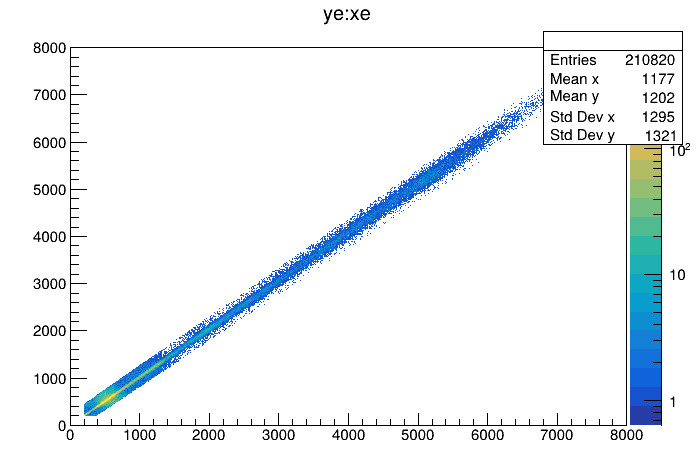

In [22]:
TCanvas *c1 = new TCanvas("c1","c1");
TFile *fin = new TFile("./data/d1xy.root");
TTree *tree =(TTree *)fin->Get("tree");
tree->Draw("ye:xe>>(1000,0,8000,1000,0,8000)","","colz");
c1->SetLogz();
c1->Draw();